 # Covid Data Analysis

 ## Prerequisite

 #### (1) Install required packages ```pyspark```, ```numpy``` and ```matplotlib```

In [27]:
%pip install pyspark
%pip install numpy
%pip install matplotlib
%pip install pandas
%pip install pyarrow


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/28.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/28.0 MB ? eta -:--:--
   ----- ---------------------------------- 4.2/28.0 MB 19.6 MB/s eta 0:00:02
   --------------- ------------------------ 11.0/28.0 MB 25.9 MB/s eta 0:00:01
   -------------------------- ------------- 18.9/28.0 MB 29.6 MB/s eta 0:00:01
   ------------------------------------ --- 25.7/28.0 MB 30.5 MB/s eta 0:00:01
   ---------------------------------------  27.8/28.0 MB 30.3 MB/s eta 0:00:01
   ---------------------------------------  27.8/28.0 MB 30.3 MB/s eta 0:00:01
   ---------------------------------------  27.8/28.0 MB 30.3 MB/s eta 0:00:01
   ---------------------------------------  27.8/28.0 MB 30.3 MB/s eta 0:00:01
   ---------------------------------------- 28.0/28.0 MB 15.2 MB/s  0:00:02
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


 #### (2) Import necessary Packages

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, count, lower, regexp_replace, trim, sum as spark_sum, max as spark_max, month, lag, dense_rank
from pyspark.sql.window import Window


 ## Module 1: Data Loading & Schema Handling

 #### (1) Load all CSV files into PySpark DataFrames

In [3]:
spark = SparkSession.builder.appName("CovidDataPipeline").getOrCreate()

dataset_directory = "./dataset"

daily_country_trends = spark.read.csv(f"{dataset_directory}/full_grouped.csv", header=True, inferSchema=True)
historical_data = spark.read.csv(f"{dataset_directory}/covid_19_clean_complete.csv", header=True, inferSchema=True)
country_statistics = spark.read.csv(f"{dataset_directory}/country_wise_latest.csv", header=True, inferSchema=True)
daily_global_trends = spark.read.csv(f"{dataset_directory}/day_wise.csv", header=True, inferSchema=True)
USA_country_data = spark.read.csv(f"{dataset_directory}/usa_county_wise.csv", header=True, inferSchema=True)
global_population_data = spark.read.csv(f"{dataset_directory}/worldometer_data.csv", header=True, inferSchema=True)

daily_country_trends.printSchema()
print("Total records in daily_country_trends:", daily_country_trends.count())

historical_data.printSchema()
print("Total records in historical_data:", historical_data.count())

country_statistics.printSchema()
print("Total records in country_statistics:", country_statistics.count())

daily_global_trends.printSchema()
print("Total records in daily_global_trends:", daily_global_trends.count())

USA_country_data.printSchema()
print("Total records in USA_country_data:", USA_country_data.count())

global_population_data.printSchema()
print("Total records in global_population_data:", global_population_data.count())


root
 |-- Date: date (nullable = true)
 |-- Country/Region: string (nullable = true)
 |-- Confirmed: integer (nullable = true)
 |-- Deaths: integer (nullable = true)
 |-- Recovered: integer (nullable = true)
 |-- Active: integer (nullable = true)
 |-- New cases: integer (nullable = true)
 |-- New deaths: integer (nullable = true)
 |-- New recovered: integer (nullable = true)
 |-- WHO Region: string (nullable = true)

Total records in daily_country_trends: 35156
root
 |-- Province/State: string (nullable = true)
 |-- Country/Region: string (nullable = true)
 |-- Lat: double (nullable = true)
 |-- Long: double (nullable = true)
 |-- Date: date (nullable = true)
 |-- Confirmed: integer (nullable = true)
 |-- Deaths: integer (nullable = true)
 |-- Recovered: integer (nullable = true)
 |-- Active: integer (nullable = true)
 |-- WHO Region: string (nullable = true)

Total records in historical_data: 49068
root
 |-- Country/Region: string (nullable = true)
 |-- Confirmed: integer (nullable = 

 ## Module 2: Data Cleaning Tasks

 #### (2) Handle Missing Province/State Values

In [4]:
historical_data.filter(col("Province/State").isNull()).select("*").show(5)
historical_data = historical_data.fillna({"Province/State": "Unknown"})
historical_data.filter(col("Province/State") == "Unknown").select("*").show(5)


+--------------+--------------+--------+---------+----------+---------+------+---------+------+--------------------+
|Province/State|Country/Region|     Lat|     Long|      Date|Confirmed|Deaths|Recovered|Active|          WHO Region|
+--------------+--------------+--------+---------+----------+---------+------+---------+------+--------------------+
|          NULL|   Afghanistan|33.93911|67.709953|2020-01-22|        0|     0|        0|     0|Eastern Mediterra...|
|          NULL|       Albania| 41.1533|  20.1683|2020-01-22|        0|     0|        0|     0|              Europe|
|          NULL|       Algeria| 28.0339|   1.6596|2020-01-22|        0|     0|        0|     0|              Africa|
|          NULL|       Andorra| 42.5063|   1.5218|2020-01-22|        0|     0|        0|     0|              Europe|
|          NULL|        Angola|-11.2027|  17.8739|2020-01-22|        0|     0|        0|     0|              Africa|
+--------------+--------------+--------+---------+----------+---

 #### (3) Standardize Country Names

In [5]:
def get_country_column(df):
    for candidate in ["Country/Region", "Country_Region", "Country", "country"]:
        if candidate in df.columns:
            return candidate
    return None

def standardize_country_name(country_col):
    cleaned_country = lower(regexp_replace(trim(country_col), r"[^A-Za-z\s]", " "))
    cleaned_country = regexp_replace(cleaned_country, r"\s+", " ")

    return (
        when(cleaned_country.isin("us", "u s", "usa", "united states", "united states of america"), "United States")
        .when(cleaned_country.isin("korea", "south korea", "s korea", "republic of korea"), "South Korea")
        .when(cleaned_country.isin("north korea", "democratic peoples republic of korea"), "North Korea")
        .otherwise(trim(country_col))
    )

target_dfs = {
    "daily_country_trends": daily_country_trends,
    "country_statistics": country_statistics,
    "global_population_data": global_population_data
}

for name, df in target_dfs.items():
    col_name = get_country_column(df)
    if col_name:
        target_dfs[name] = df.withColumn(col_name, standardize_country_name(col(col_name)))

daily_country_trends = target_dfs["daily_country_trends"]
country_statistics = target_dfs["country_statistics"]
global_population_data = target_dfs["global_population_data"]


 #### (4) Remove Duplicate Daily Records

In [6]:
daily_country_trends = daily_country_trends.dropDuplicates(["Country/Region", "Date"])
print("Total records after removing duplicates:", daily_country_trends.count())


Total records after removing duplicates: 35156


 ## Module 3: Aggregation Tasks

 #### (5) Top 10 Countries by Total Confirmed Cases

,Country/Region,Confirmed
0,United States,4290259
1,Brazil,2442375
2,India,1480073
3,Russia,816680
4,South Africa,452529
5,Mexico,395489
6,Peru,389717
7,Chile,347923
8,United Kingdom,301708
9,Iran,293606


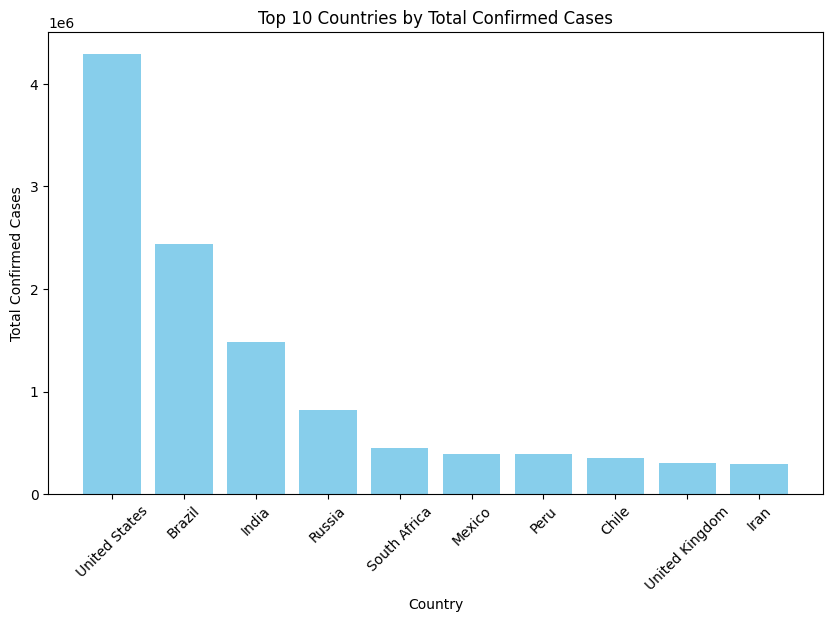

In [7]:
top_10_confirmed_pandas = country_statistics.select("Country/Region", "Confirmed") \
    .orderBy(col("Confirmed").desc()) \
    .limit(10) \
    .toPandas()

display(top_10_confirmed_pandas)

plt.figure(figsize=(10, 6))
plt.bar(top_10_confirmed_pandas["Country/Region"], top_10_confirmed_pandas["Confirmed"], color='skyblue')
plt.xlabel("Country")
plt.ylabel("Total Confirmed Cases")
plt.title("Top 10 Countries by Total Confirmed Cases")
plt.xticks(rotation=45)
plt.show()


 #### (6) Top 10 Countries by Death Rate

,Country/Region,Deaths / 100 Cases
0,Yemen,28.56
1,United Kingdom,15.19
2,Belgium,14.79
3,Italy,14.26
4,France,13.71
5,Hungary,13.40
6,Netherlands,11.53
7,Mexico,11.13
8,Spain,10.44
9,Western Sahara,10.00


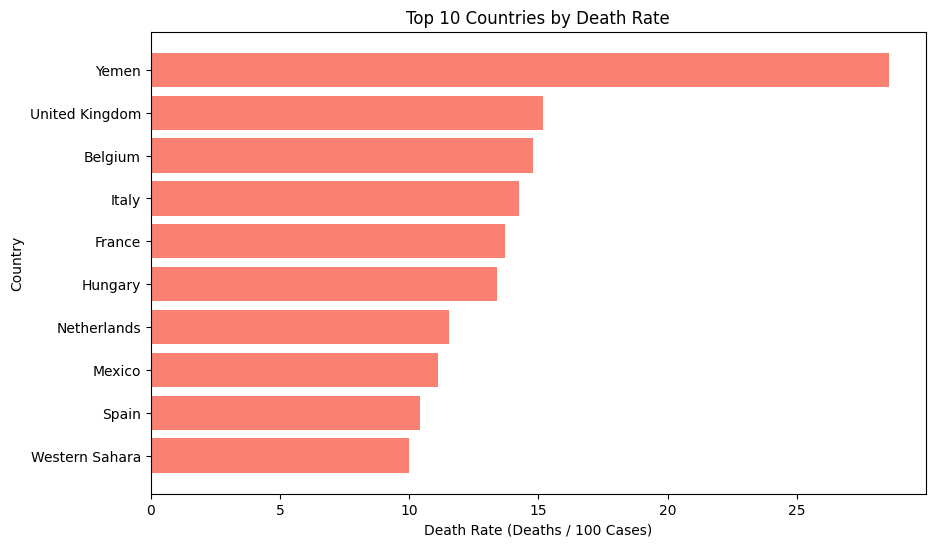

In [8]:
top_10_death_rate_pandas = country_statistics.select("Country/Region", "Deaths / 100 Cases") \
    .orderBy(col("Deaths / 100 Cases").desc()) \
    .limit(10) \
    .toPandas()

display(top_10_death_rate_pandas)

plt.figure(figsize=(10, 6))
plt.barh(top_10_death_rate_pandas["Country/Region"], top_10_death_rate_pandas["Deaths / 100 Cases"], color='salmon')
plt.xlabel("Death Rate (Deaths / 100 Cases)")
plt.ylabel("Country")
plt.title("Top 10 Countries by Death Rate")
plt.gca().invert_yaxis()
plt.show()


 #### (7) WHO Region-wise Total Cases

,WHO Region,Total_Confirmed,Total_Deaths,Total_Recovered
0,Europe,3299523,211465,2009289
1,Western Pacific,292428,8250,206770
2,Africa,723211,12223,440730
3,Eastern Mediterranean,1490791,38339,1201400
4,Americas,8839286,342732,4468616
5,South-East Asia,1835297,41349,1156933


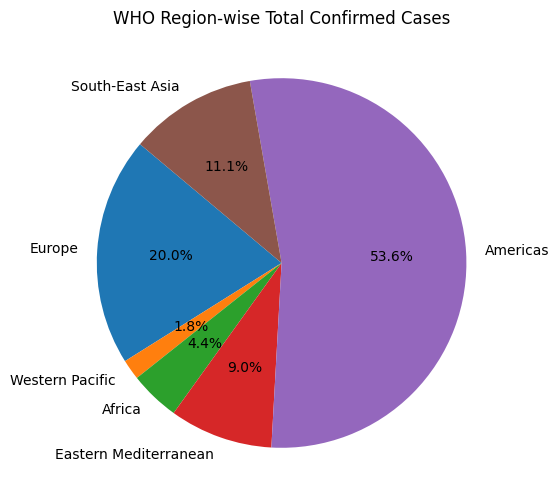

In [9]:
who_region_cases = daily_country_trends.groupBy("WHO Region", "Country/Region") \
    .agg(
        spark_max("Confirmed").alias("Max_Confirmed"),
        spark_max("Deaths").alias("Max_Deaths"),
        spark_max("Recovered").alias("Max_Recovered")
    ) \
    .groupBy("WHO Region") \
    .agg(
        spark_sum("Max_Confirmed").alias("Total_Confirmed"),
        spark_sum("Max_Deaths").alias("Total_Deaths"),
        spark_sum("Max_Recovered").alias("Total_Recovered")
    ) \
    .toPandas()

display(who_region_cases)

plt.figure(figsize=(10, 6))
plt.pie(who_region_cases["Total_Confirmed"], labels=who_region_cases["WHO Region"], autopct='%1.1f%%', startangle=140)
plt.title("WHO Region-wise Total Confirmed Cases")
plt.show()


 ## Module 4: Time-Series Analysis

 #### (8) Daily Global New Cases Trend

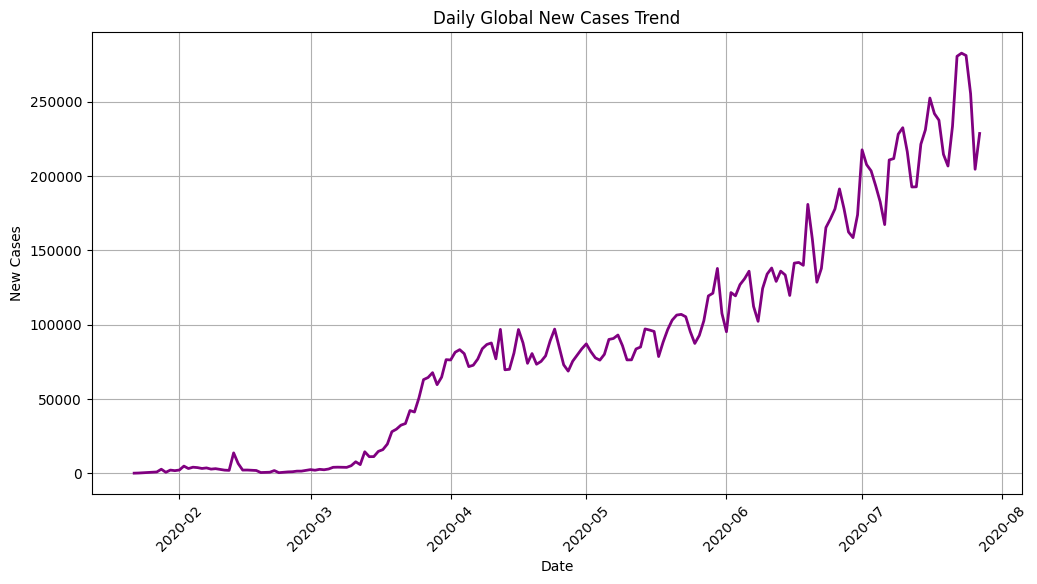

In [10]:
daily_new_cases_pandas = daily_global_trends.select("Date", "New cases").toPandas()
daily_new_cases_pandas["Date"] = pd.to_datetime(daily_new_cases_pandas["Date"])

plt.figure(figsize=(12, 6))
plt.plot(daily_new_cases_pandas["Date"], daily_new_cases_pandas["New cases"], color='purple', linewidth=2)
plt.xlabel("Date")
plt.ylabel("New Cases")
plt.title("Daily Global New Cases Trend")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


 #### (9) Daily Global Death Growth Trend

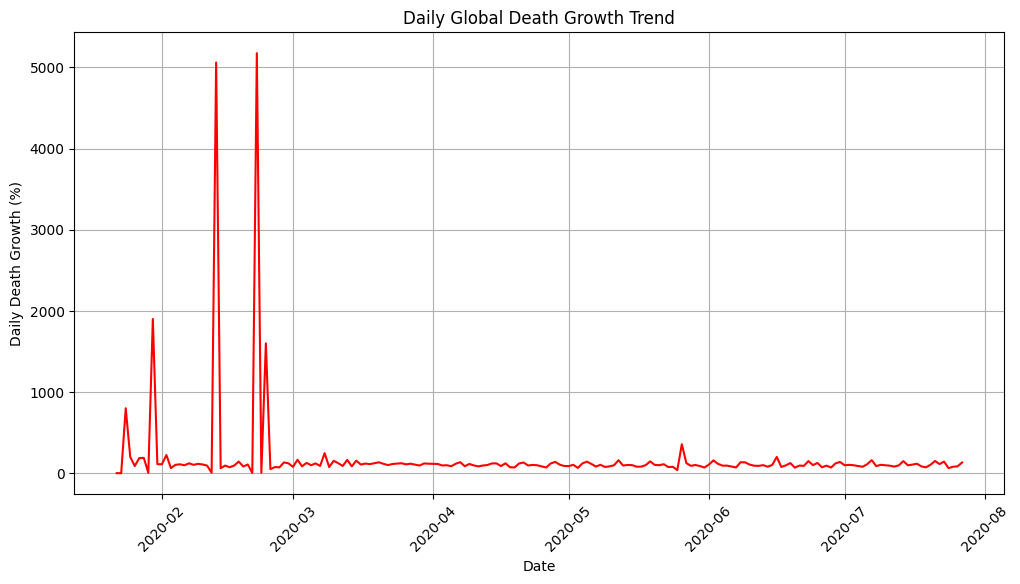

In [12]:
window_spec = Window.orderBy("Date")

daily_death_growth = daily_global_trends.withColumn("Previous_Day_Deaths", lag("New deaths")
                                                    .over(window_spec)).withColumn("Death_Growth_Pct",
                                                        when(col("Previous_Day_Deaths") == 0, 0)
                                                    .otherwise((col("New deaths") / col("Previous_Day_Deaths")) * 100)).fillna({"Death_Growth_Pct": 0}).toPandas()

daily_death_growth["Date"] = pd.to_datetime(daily_death_growth["Date"])

plt.figure(figsize=(12, 6))
plt.plot(daily_death_growth["Date"], daily_death_growth["Death_Growth_Pct"], color='red', linewidth=1.5)
plt.xlabel("Date")
plt.ylabel("Daily Death Growth (%)")
plt.title("Daily Global Death Growth Trend")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

 #### (10) Monthly COVID Case Growth

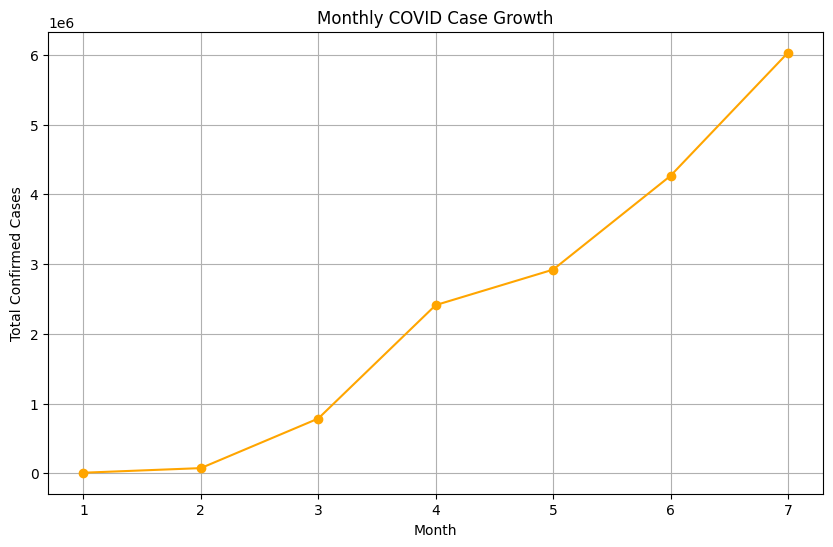

In [13]:
monthly_case_growth = daily_country_trends.withColumn("Month", month("Date")) \
    .groupBy("Month") \
    .agg(spark_sum("New cases").alias("Monthly_Confirmed")) \
    .orderBy("Month") \
    .toPandas()

plt.figure(figsize=(10, 6))
plt.plot(monthly_case_growth["Month"], monthly_case_growth["Monthly_Confirmed"], marker='o', linestyle='-', color='orange')
plt.xlabel("Month")
plt.ylabel("Total Confirmed Cases")
plt.title("Monthly COVID Case Growth")
plt.xticks(monthly_case_growth["Month"])
plt.grid(True)
plt.show()


 ## Module 5: Window Function Tasks

 #### (11) Top 5 Most Affected Countries Per WHO Region

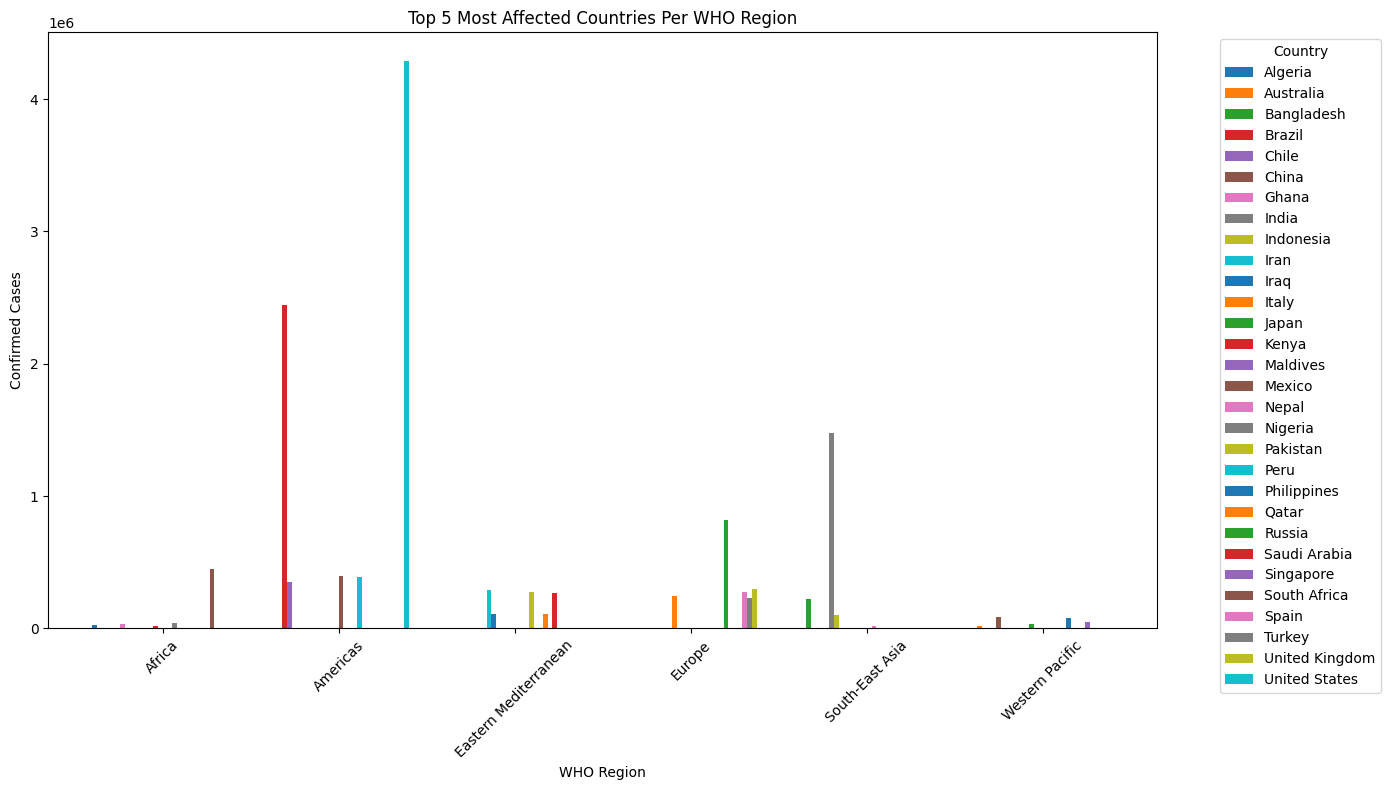

In [14]:
window_region = Window.partitionBy("WHO Region").orderBy(col("Confirmed").desc())

top_5_per_region = country_statistics.withColumn("Rank", dense_rank().over(window_region)) \
    .filter(col("Rank") <= 5) \
    .toPandas()

pivot_df = top_5_per_region.pivot(index='WHO Region', columns='Country/Region', values='Confirmed')

pivot_df.plot(kind='bar', figsize=(14, 8), width=0.8)
plt.title("Top 5 Most Affected Countries Per WHO Region")
plt.ylabel("Confirmed Cases")
plt.xlabel("WHO Region")
plt.xticks(rotation=45)
plt.legend(title="Country", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


 #### (12) Country-wise Daily Case Increase

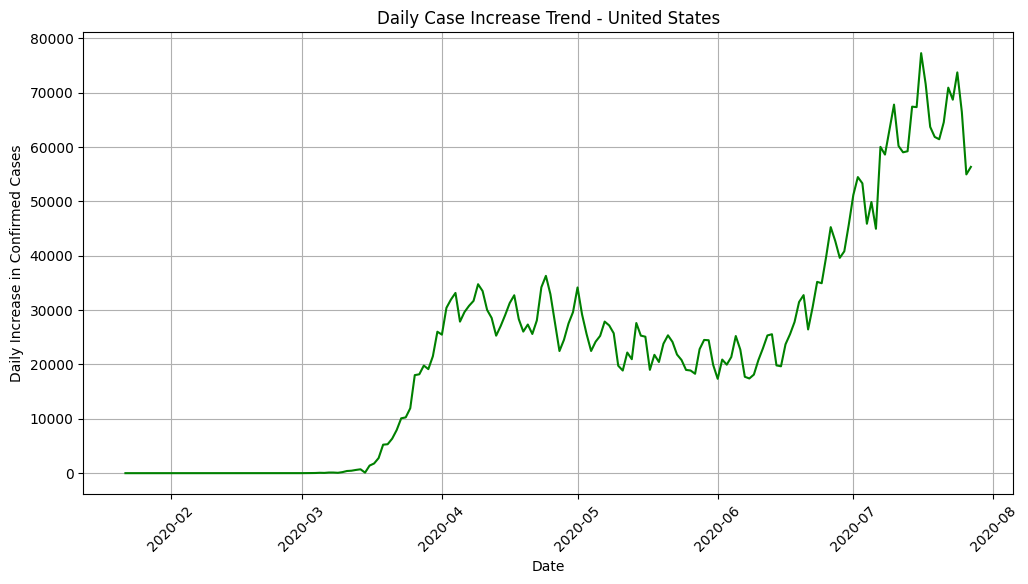

In [15]:
window_country = Window.partitionBy("Country/Region").orderBy("Date")

daily_increase_df = daily_country_trends.withColumn("Yesterday_Confirmed", lag("Confirmed").over(window_country)) \
    .withColumn("Daily_Increase", col("Confirmed") - col("Yesterday_Confirmed")) \
    .fillna({"Daily_Increase": 0})

us_trend = daily_increase_df.filter(col("Country/Region") == "United States").toPandas()
us_trend["Date"] = pd.to_datetime(us_trend["Date"])

plt.figure(figsize=(12, 6))
plt.plot(us_trend["Date"], us_trend["Daily_Increase"], color='green')
plt.title("Daily Case Increase Trend - United States")
plt.xlabel("Date")
plt.ylabel("Daily Increase in Confirmed Cases")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


 ## Module 6: Join Operations

 #### (13) Compare Latest Dataset Sources

In [16]:
worldometer_clean = global_population_data.select(
    col("Country/Region").alias("Worldometer_Country"),
    col("TotalCases").alias("Worldometer_Confirmed"),
    col("TotalDeaths").alias("Worldometer_Deaths"),
    col("TotalRecovered").alias("Worldometer_Recovered")
)

comparison_df = country_statistics.join(
    worldometer_clean, 
    country_statistics["Country/Region"] == worldometer_clean["Worldometer_Country"], 
    "inner"
)

comparison_df = comparison_df.withColumn("Confirmed_Diff", col("Confirmed") - col("Worldometer_Confirmed")) \
    .withColumn("Deaths_Diff", col("Deaths") - col("Worldometer_Deaths")) \
    .withColumn("Recovered_Diff", col("Recovered") - col("Worldometer_Recovered"))

mismatches = comparison_df.select("Country/Region", "Confirmed_Diff", "Deaths_Diff", "Recovered_Diff") \
    .filter((col("Confirmed_Diff") != 0) | (col("Deaths_Diff") != 0) | (col("Recovered_Diff") != 0))

display(mismatches.show(10))


+--------------+--------------+-----------+--------------+
|Country/Region|Confirmed_Diff|Deaths_Diff|Recovered_Diff|
+--------------+--------------+-----------+--------------+
| United States|       -741920|     -14793|      -1250864|
|        Brazil|       -475187|     -11026|       -201019|
|         India|       -545336|      -8230|       -426218|
|        Russia|        -55214|      -1272|        -74108|
|  South Africa|        -85655|      -2537|       -112391|
|        Mexico|        -67201|      -6495|         -5038|
|          Peru|        -65692|      -2006|        -37790|
|         Chile|        -18748|       -702|        -20214|
|      Colombia|       -100609|      -3162|        -61194|
|         Spain|        -82109|        -68|          NULL|
+--------------+--------------+-----------+--------------+
only showing top 10 rows


None

 #### (14) Population vs Total Cases

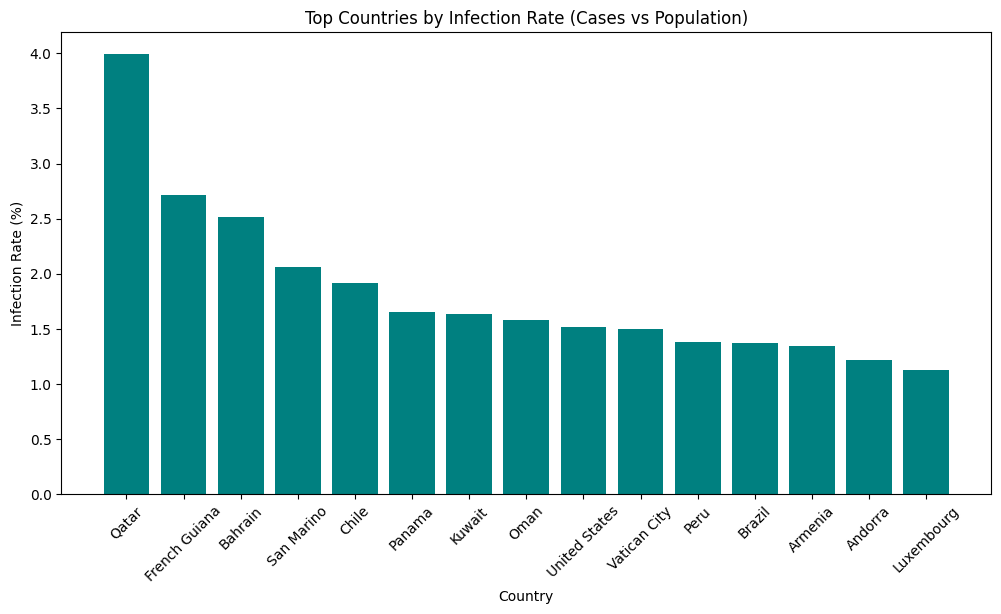

In [17]:
infection_rate_df = global_population_data.withColumn("Infection_Rate", (col("TotalCases") / col("Population")) * 100) \
    .orderBy(col("Infection_Rate").desc()) \
    .limit(15) \
    .toPandas()

plt.figure(figsize=(12, 6))
plt.bar(infection_rate_df["Country/Region"], infection_rate_df["Infection_Rate"], color='teal')
plt.title("Top Countries by Infection Rate (Cases vs Population)")
plt.xlabel("Country")
plt.ylabel("Infection Rate (%)")
plt.xticks(rotation=45)
plt.show()


 ## Module 7: Geographic Analysis

 #### (15) USA State-wise Case Distribution

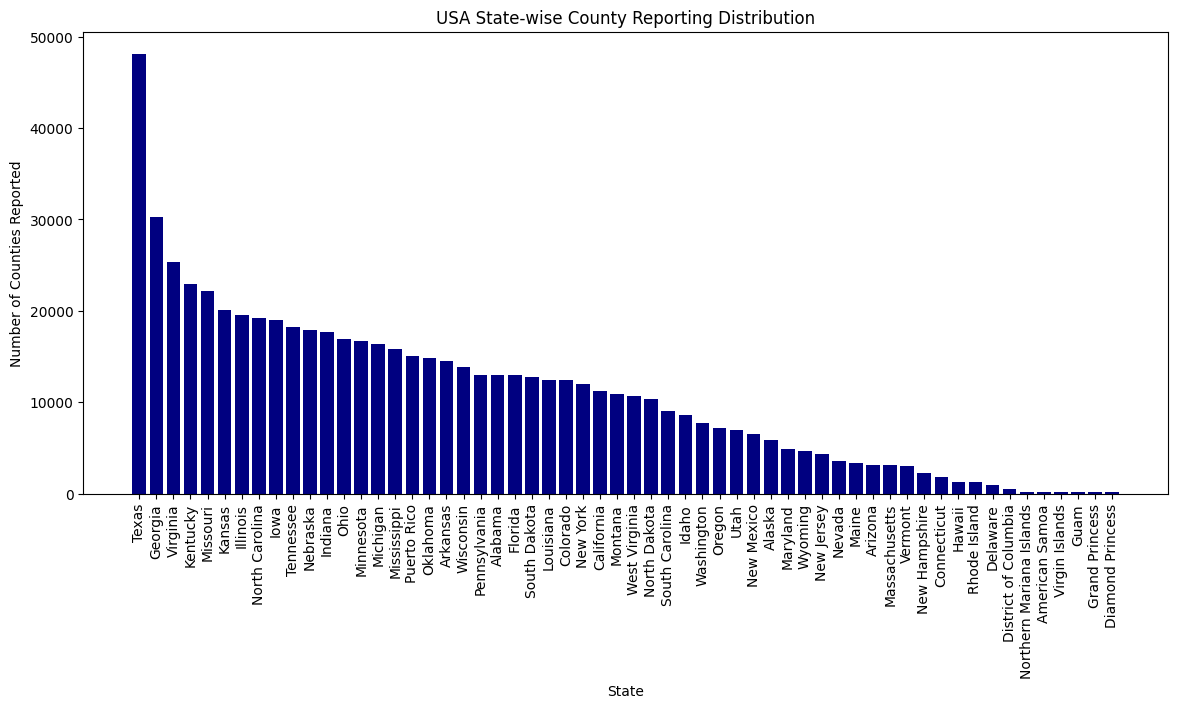

In [18]:
state_distribution = USA_country_data.groupBy("Province_State").count() \
    .orderBy(col("count").desc()) \
    .toPandas()

plt.figure(figsize=(14, 6))
plt.bar(state_distribution["Province_State"], state_distribution["count"], color='navy')
plt.title("USA State-wise County Reporting Distribution")
plt.xlabel("State")
plt.ylabel("Number of Counties Reported")
plt.xticks(rotation=90)
plt.show()


 #### (16) Latitude-Longitude Based Case Clusters

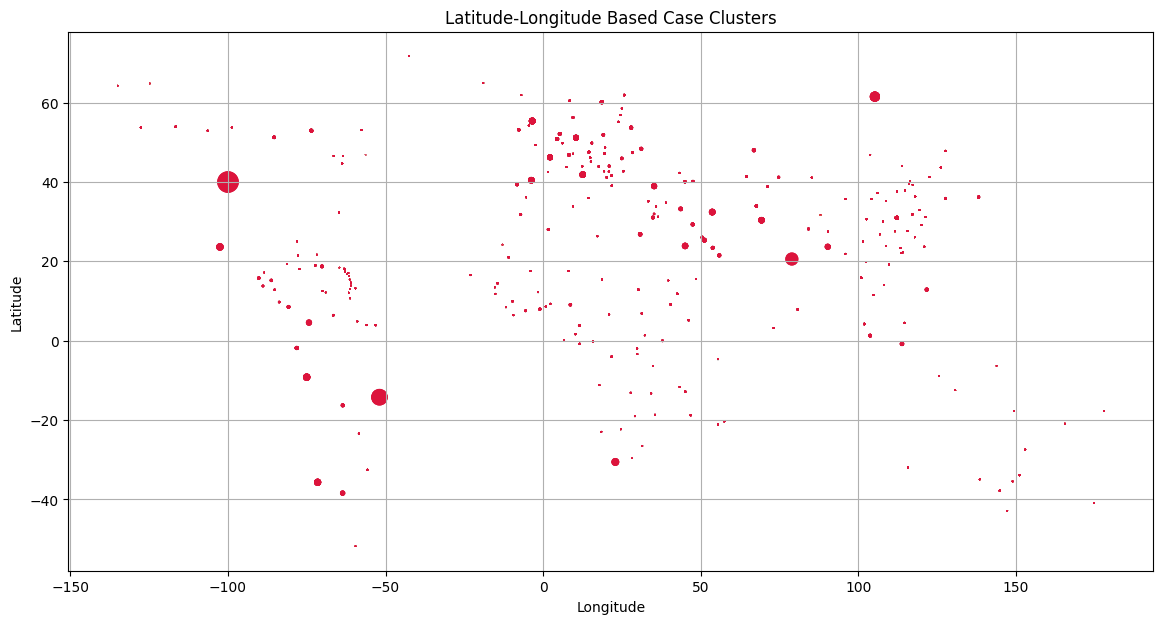

In [19]:
geo_data = historical_data.select("Lat", "Long", "Confirmed").dropna().toPandas()

plt.figure(figsize=(14, 7))
plt.scatter(geo_data["Long"], geo_data["Lat"], s=geo_data["Confirmed"]/20000, alpha=0.5, color='crimson')
plt.title("Latitude-Longitude Based Case Clusters")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.show()


 ## Module 8: Advanced Analytical Tasks

 #### (17) Recovery Rate Analysis

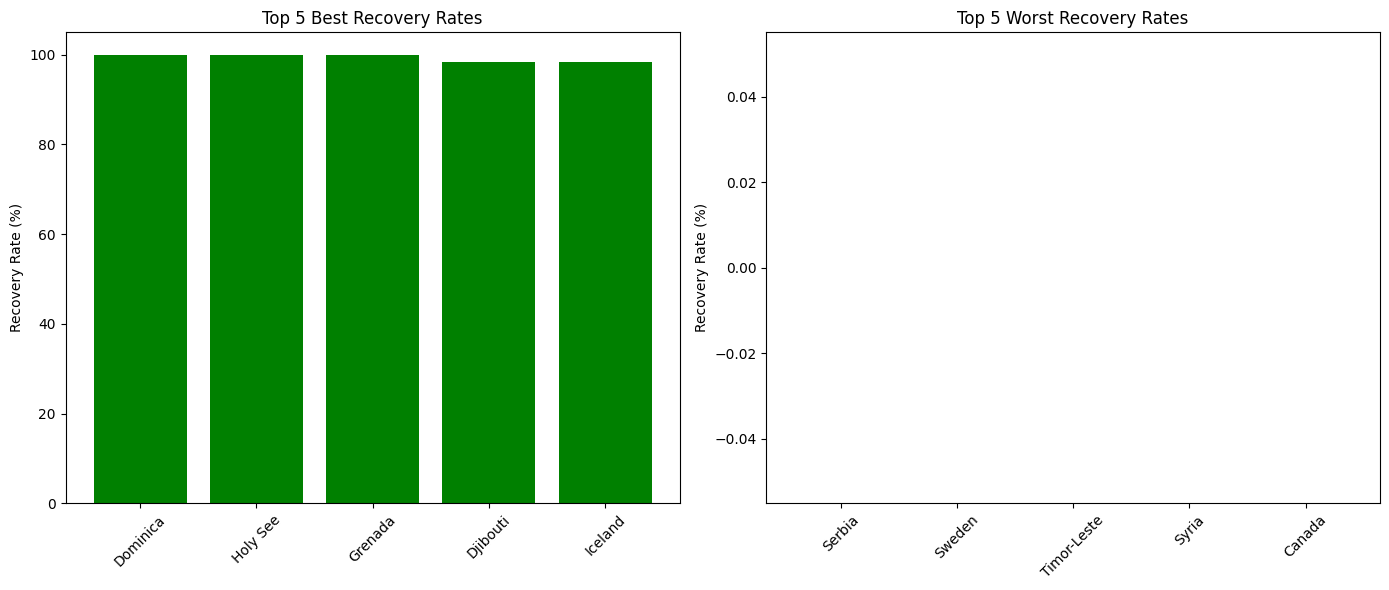

In [20]:
recovery_analysis = country_statistics.withColumn("Recovery_Rate", (col("Recovered") / col("Confirmed")) * 100)

best_recovery = recovery_analysis.orderBy(col("Recovery_Rate").desc()).limit(5).toPandas()
worst_recovery = recovery_analysis.filter(col("Recovery_Rate").isNotNull()).orderBy(col("Recovery_Rate").asc()).limit(5).toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].bar(best_recovery["Country/Region"], best_recovery["Recovery_Rate"], color='green')
axes[0].set_title("Top 5 Best Recovery Rates")
axes[0].set_ylabel("Recovery Rate (%)")
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(worst_recovery["Country/Region"], worst_recovery["Recovery_Rate"], color='darkred')
axes[1].set_title("Top 5 Worst Recovery Rates")
axes[1].set_ylabel("Recovery Rate (%)")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


 #### (18) Active Case Burden Analysis

In [21]:
high_risk_countries = country_statistics.filter(col("Active") > col("Recovered")) \
    .select("Country/Region", "Active", "Recovered", "Confirmed") \
    .orderBy(col("Active").desc())

display(high_risk_countries.show(10))


+--------------+-------+---------+---------+
|Country/Region| Active|Recovered|Confirmed|
+--------------+-------+---------+---------+
| United States|2816444|  1325804|  4290259|
|United Kingdom| 254427|     1437|   301708|
|        France| 108928|    81212|   220352|
|        Canada| 107514|        0|   116458|
|     Argentina|  91782|    72575|   167416|
|        Sweden|  73695|        0|    79395|
|   Philippines|  53649|    26446|    82040|
|         Egypt|  52992|    34838|    92482|
|   Netherlands|  47064|      189|    53413|
|       Bolivia|  47056|    21478|    71181|
+--------------+-------+---------+---------+
only showing top 10 rows


None

 #### (19) Identify Pandemic Peaks

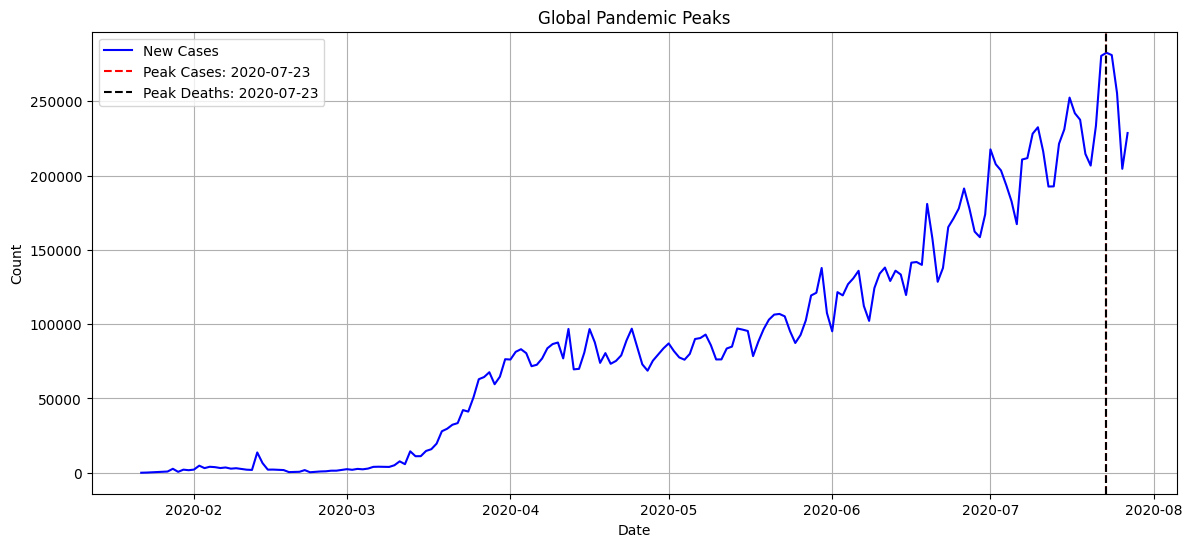

In [22]:
max_cases_row = daily_global_trends.orderBy(col("New cases").desc()).first()
max_deaths_row = daily_global_trends.orderBy(col("New deaths").desc()).first()

peak_cases_date = max_cases_row["Date"]
peak_deaths_date = max_deaths_row["Date"]

daily_global_pd = daily_global_trends.toPandas()
daily_global_pd["Date"] = pd.to_datetime(daily_global_pd["Date"])

plt.figure(figsize=(14, 6))
plt.plot(daily_global_pd["Date"], daily_global_pd["New cases"], label="New Cases", color='blue')
plt.axvline(pd.to_datetime(peak_cases_date), color='red', linestyle='--', label=f"Peak Cases: {peak_cases_date}")
plt.axvline(pd.to_datetime(peak_deaths_date), color='black', linestyle='--', label=f"Peak Deaths: {peak_deaths_date}")
plt.title("Global Pandemic Peaks")
plt.xlabel("Date")
plt.ylabel("Count")
plt.legend()
plt.grid(True)
plt.show()


 ## Module 9: Feature Engineering

 #### (20) Create Severity Category

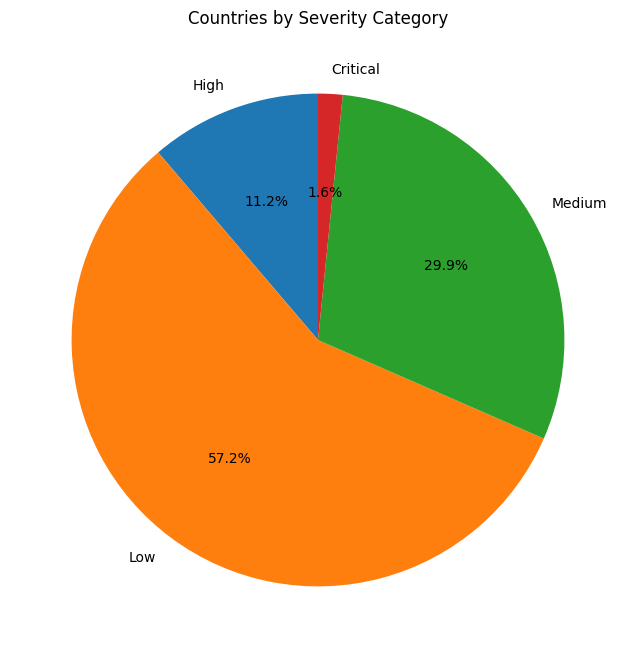

In [23]:
severity_df = country_statistics.withColumn("Severity_Category",
    when(col("Confirmed") < 10000, "Low")
    .when((col("Confirmed") >= 10000) & (col("Confirmed") <= 100000), "Medium")
    .when((col("Confirmed") > 100000) & (col("Confirmed") <= 1000000), "High")
    .otherwise("Critical")
)

severity_counts = severity_df.groupBy("Severity_Category").count().toPandas()

plt.figure(figsize=(8, 8))
plt.pie(severity_counts["count"], labels=severity_counts["Severity_Category"], autopct='%1.1f%%', startangle=90)
plt.title("Countries by Severity Category")
plt.show()


 ## Module 10: Final Mini Pipeline Project

 #### (21) Build COVID Analytics Pipeline Outputs

In [29]:
import os

output_dir = "./pipeline_output"
os.makedirs(output_dir, exist_ok=True)

top_10_countries = country_statistics.select("Country/Region", "Confirmed", "Deaths", "Recovered").orderBy(col("Confirmed").desc()).limit(10)

region_summary = daily_country_trends.groupBy("WHO Region").agg(spark_sum("New cases").alias("Total_Confirmed"), spark_sum("New deaths").alias("Total_Deaths"))

mortality_report = country_statistics.withColumn("Mortality_Rate", (col("Deaths") / col("Confirmed")) * 100).select("Country/Region", "Confirmed", "Deaths", "Mortality_Rate")

top_10_countries.toPandas().to_csv(f"{output_dir}/top_10_countries.csv", index=False)
region_summary.toPandas().to_csv(f"{output_dir}/region_summary.csv", index=False)
mortality_report.toPandas().to_csv(f"{output_dir}/mortality_report.csv", index=False)
daily_global_trends.toPandas().to_csv(f"{output_dir}/daily_trends.csv", index=False)

print(f"Pipeline executed successfully. All files exported as CSV to {output_dir}")

Pipeline executed successfully. All files exported as CSV to ./pipeline_output
